# JSON Output Consistency: Analysis

Loads **every** run under `results/` (filter via `RUN_FILTER` below) and compares
them side by side; each run is labeled `model @ flat-item-count`. Sections:

1. Schema-valid rate per run across 0/1/2-shot variants
2. Determinism (share of iterations matching the modal output) by sampling config
3. Extraction mode (raw vs fenced vs embedded JSON) per run and shot mode
4. Latency and output length distributions
5. Stream health: time-to-first-token, worst mid-flight gaps, stalls and errors by phase
6. Failure drill-down

Works on partial results from an interrupted run (rows are appended live).
Re-run top to bottom after each `runner.py` run; fully repeatable.

In [1]:
from pathlib import Path
import json
import pandas as pd
import matplotlib.pyplot as plt

RUN_FILTER = None  # e.g. ["20260821T110511Z"] to restrict; None = all runs


def run_label(rd: Path) -> str:
    meta = json.load(open(rd / "meta.json"))
    cfg = json.load(open(rd / "config.json"))
    flat = next(t for t in cfg["tasks"] if t["name"] == "flat_inventory")
    model = (meta.get("model_filter") or "all-models").removeprefix("claude-")
    return f"{model} @{flat['schema']['maxItems']}"


frames = []
for rd in sorted(Path("results").iterdir()):
    if RUN_FILTER and rd.name not in RUN_FILTER:
        continue
    f = rd / "results.jsonl"
    if not f.exists() or f.stat().st_size == 0:
        continue
    sub = pd.read_json(f, lines=True)
    sub["run"] = run_label(rd)
    sub["run_dir"] = rd.name
    frames.append(sub)

df = pd.concat(frames, ignore_index=True)
RUNS = list(dict.fromkeys(df["run"]))
print(f"{len(frames)} run(s), {len(df)} rows: {RUNS}")
df.groupby(["run", "task"]).agg(rows=("iteration", "count"),
                                valid=("schema_ok", "sum"))

2 run(s), 72 rows: ['sonnet-4-6 @300', 'haiku-4-5 @600']


rows  valid
run             task                       
haiku-4-5 @600  flat_inventory    18     12
                nested_org        18      6
sonnet-4-6 @300 flat_inventory    18     12
                nested_org        18     18

In [2]:
# Chart style: validated categorical palette, recessive chrome, thin marks.
SERIES = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100"]  # blue, orange, aqua, yellow
SURFACE, INK, MUTED, GRID = "#fcfcfb", "#0b0b0b", "#898781", "#e1e0d9"

plt.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE,
    "text.color": INK, "axes.labelcolor": MUTED,
    "xtick.color": MUTED, "ytick.color": MUTED,
    "axes.edgecolor": GRID, "axes.grid": True, "grid.color": GRID,
    "grid.linewidth": 0.6, "axes.axisbelow": True,
    "axes.spines.top": False, "axes.spines.right": False,
    "font.family": "sans-serif", "figure.dpi": 110,
})

def grouped_bars(ax, pivot, colors=SERIES, ylabel="", pct=False):
    """Grouped bar chart from a pivot (index = x groups, columns = series)."""
    n = len(pivot.columns)
    width = 0.8 / n
    for i, col in enumerate(pivot.columns):
        x = [j + i * width for j in range(len(pivot))]
        ax.bar(x, pivot[col], width=width * 0.92, color=colors[i % len(colors)], label=str(col))
    ax.set_xticks([j + 0.4 - width / 2 for j in range(len(pivot))])
    ax.set_xticklabels(pivot.index, color=INK)
    ax.set_ylabel(ylabel)
    if pct:
        ax.set_ylim(0, 1.02)
        ax.yaxis.set_major_formatter(lambda v, _: f"{v:.0%}")
    ax.grid(axis="x", visible=False)
    if n > 1:
        ax.legend(frameon=False, labelcolor=INK)

def boxes_by_run(ax, sub, col, label):
    """One box per run for metric `col`."""
    data = [sub.loc[sub["run"] == r, col].dropna() for r in RUNS]
    bp = ax.boxplot(data, tick_labels=RUNS, patch_artist=True, widths=0.45,
                    medianprops={"color": INK, "linewidth": 1.4},
                    flierprops={"markersize": 3, "markerfacecolor": MUTED,
                                "markeredgecolor": "none"})
    for patch, color in zip(bp["boxes"], SERIES):
        patch.set_facecolor(color); patch.set_edgecolor("none")
    ax.set_ylabel(label)
    ax.grid(axis="x", visible=False)
    ax.tick_params(axis="x", labelcolor=INK)

## 1. Schema-valid rate: runs side by side, 0/1/2-shot as series

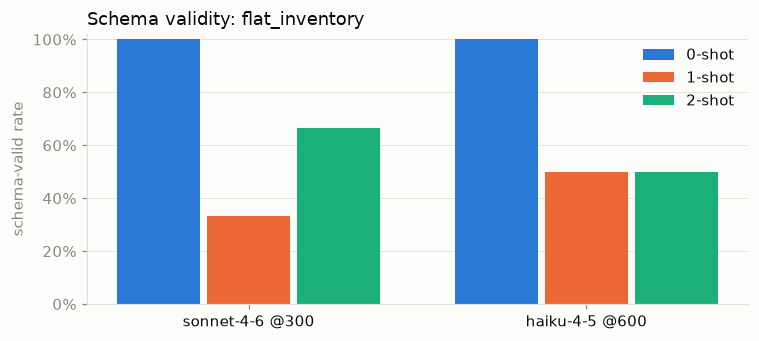

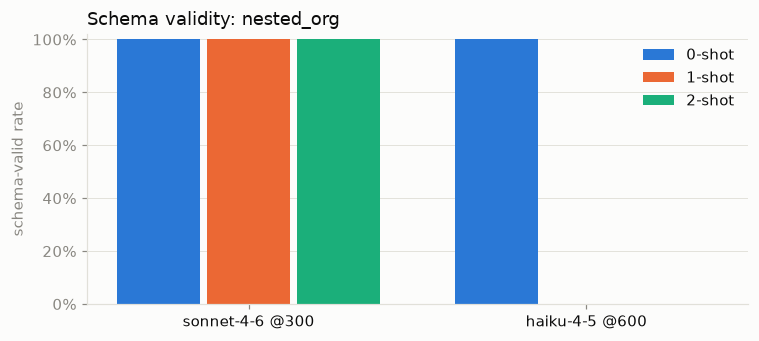

In [3]:
for task, sub in df.groupby("task"):
    pivot = (sub.pivot_table(index="run", columns="shots", values="schema_ok", aggfunc="mean")
                .reindex(RUNS))
    pivot.columns = [f"{s}-shot" for s in pivot.columns]
    fig, ax = plt.subplots(figsize=(7, 3.2))
    grouped_bars(ax, pivot, ylabel="schema-valid rate", pct=True)
    ax.set_title(f"Schema validity: {task}", color=INK, loc="left")
    plt.tight_layout()
plt.show()

## 2. Determinism by sampling config

Share of iterations whose canonical (sorted-key) JSON matches the modal output of
the cell. 1.0 = fully deterministic content; near `1/N` = every run different.

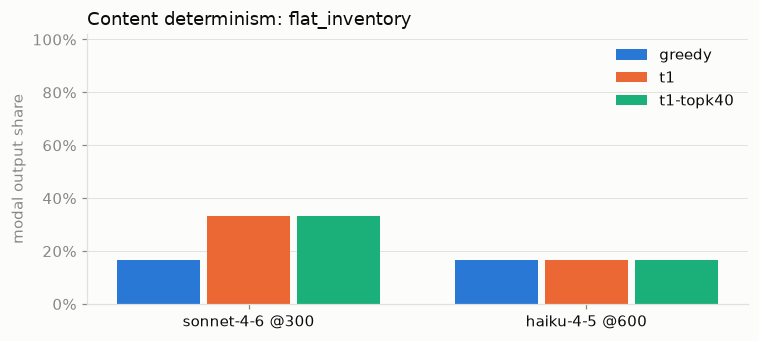

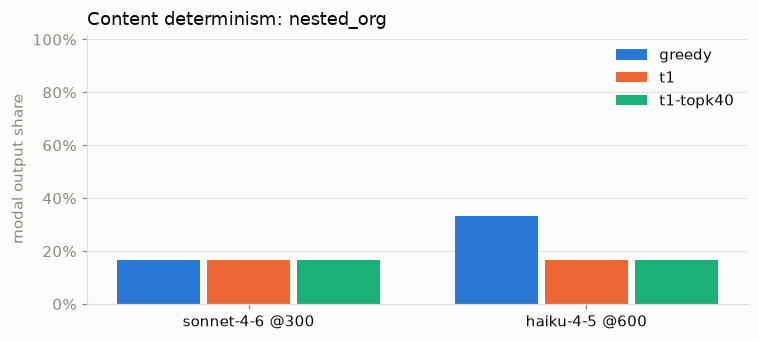

In [4]:
def modal_share(hashes: pd.Series) -> float:
    h = hashes.dropna()
    return h.value_counts().iloc[0] / len(h) if len(h) else 0.0

det = (df.groupby(["task", "run", "sampling"])["canonical_hash"]
         .apply(modal_share).rename("modal_share").reset_index())
for task, sub in det.groupby("task"):
    pivot = sub.pivot_table(index="run", columns="sampling", values="modal_share").reindex(RUNS)
    fig, ax = plt.subplots(figsize=(7, 3.2))
    grouped_bars(ax, pivot, ylabel="modal output share", pct=True)
    ax.set_title(f"Content determinism: {task}", color=INK, loc="left")
    plt.tight_layout()
plt.show()

## 3. Extraction mode (formatting discipline) per run and shot mode

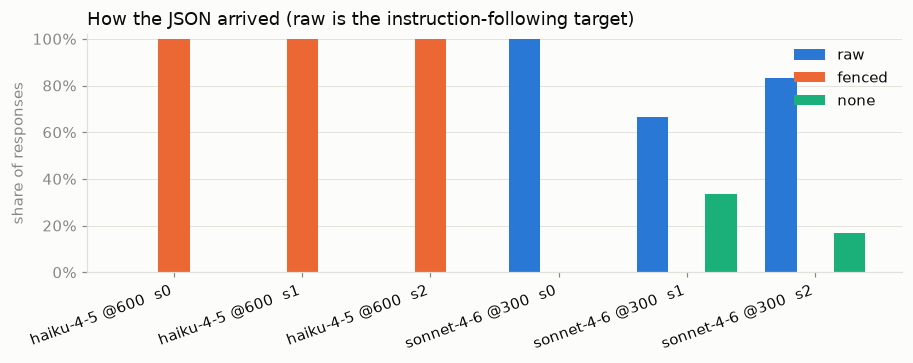

In [5]:
modes = ["raw", "fenced", "embedded", "none"]
sub = df[df["extraction"].notna()].copy()
sub["cell"] = sub["run"] + "  s" + sub["shots"].astype(str)
pivot = (sub.pivot_table(index="cell", columns="extraction", values="iteration",
                         aggfunc="count", fill_value=0)
            .reindex(columns=[m for m in modes if m in sub["extraction"].unique()], fill_value=0))
pivot = pivot.div(pivot.sum(axis=1), axis=0)
fig, ax = plt.subplots(figsize=(max(7, 1.4 * len(pivot)), 3.4))
grouped_bars(ax, pivot, ylabel="share of responses", pct=True)
ax.set_title("How the JSON arrived (raw is the instruction-following target)", color=INK, loc="left")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()

## 4. Latency and output length

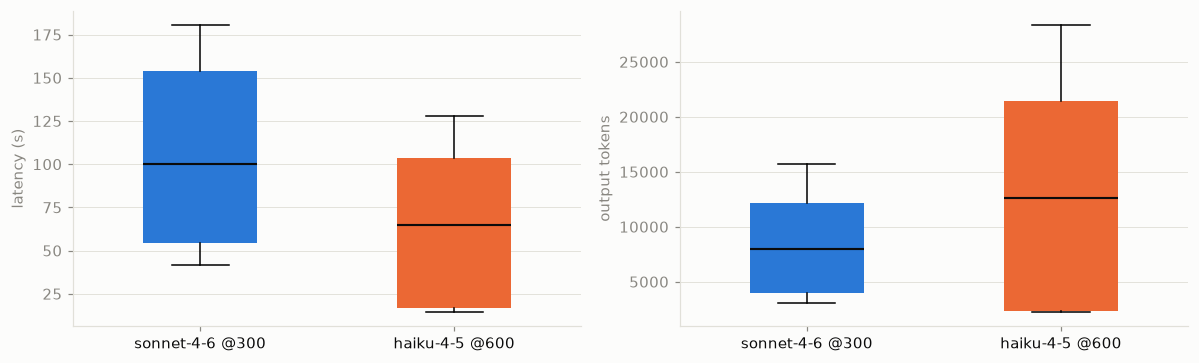

In [6]:
ok = df[df["latency_s"].notna() & df["error"].isna()]
fig, axes = plt.subplots(1, 2, figsize=(11, 3.4))
boxes_by_run(axes[0], ok, "latency_s", "latency (s)")
boxes_by_run(axes[1], ok, "output_tokens", "output tokens")
plt.tight_layout()
plt.show()

## 6. Failure drill-down

In [7]:
failures = df[~df["schema_ok"].fillna(False)]
print(f"{len(failures)} failing iterations ({len(failures)/len(df):.1%})")
if len(failures):
    display(failures.groupby(["run", "task", "shots"]).size().rename("failures").reset_index())
    display(failures.groupby("run")["schema_error"].value_counts().groupby("run").head(5))
# Every raw response (valid, invalid, and partial) is stored under
# results/<run_dir>/outputs/; each row's `output_file` column points to its file.

24 failing iterations (33.3%)


,run,task,shots,failures
0,haiku-4-5 @600,flat_inventory,1,3
1,haiku-4-5 @600,flat_inventory,2,3
2,haiku-4-5 @600,nested_org,1,6
3,haiku-4-5 @600,nested_org,2,6
4,sonnet-4-6 @300,flat_inventory,1,4
5,sonnet-4-6 @300,flat_inventory,2,2


run             schema_error                                                                                                                                                                                                         
haiku-4-5 @600  355: 'category' is a required property                                                                                                                                                                                   1
                departments: [{'name': 'Operations', 'budget': 8500000, 'teams': [{'name': 'Route Planning', 'members': [{'name': 'Marcus Johnson', 'role': 'Senior Logistics Coordinator', 'years_experience': 18}, {'name': 'Sarah     1
                departments: [{'name': 'Operations', 'budget': 8500000, 'teams': [{'name': 'Warehouse Management', 'members': [{'name': 'David Martinez', 'role': 'Warehouse Director', 'years_experience': 22}, {'name': 'Sarah Chen    1
                departments: [{'name': 'Operations', 'budget': 85

## 5. Failure drill-down

In [8]:
failures = df[~df["schema_ok"].fillna(False)]
print(f"{len(failures)} failing iterations ({len(failures)/len(df):.1%})")
if len(failures):
    display(failures.groupby(["model", "task", "shots"]).size().rename("failures").reset_index())
    display(failures["schema_error"].value_counts().head(10))
    display(failures["error"].value_counts().head(10))  # transport/API errors, if any
# Raw text of every failure is under: RUN_DIR / 'failures/'

24 failing iterations (33.3%)


,model,task,shots,failures
0,claude-haiku-4-5,flat_inventory,1,3
1,claude-haiku-4-5,flat_inventory,2,3
2,claude-haiku-4-5,nested_org,1,6
3,claude-haiku-4-5,nested_org,2,6
4,claude-sonnet-4-6,flat_inventory,1,4
5,claude-sonnet-4-6,flat_inventory,2,2


schema_error
355: 'category' is a required property                                                                                                                                                                                   1
203: 'category' is a required property                                                                                                                                                                                   1
292: 'price' is a required property                                                                                                                                                                                      1
239: 'category' is a required property                                                                                                                                                                                   1
233: 'price' is a required property                                                                            

Series([], Name: count, dtype: int64)